In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import umap
import os
import scipy
import matplotlib as mpl

In [2]:
df1 = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datasets/2p2idb/2p2idb_2024-04-08.csv', sep=";")
df2 = pd.read_csv('ppi_inhibitor_mapping.csv')

df_2p2idb = df2.merge(df1[['PDBProtProt', 'PDBProtLig', 'InChI']], on=['PDBProtProt', 'PDBProtLig'], how='left')
df_2p2idb = df_2p2idb[df_2p2idb['PDBProtProt'] != 'na']

In [3]:
df_2p2idb

,2P2IDB_ID,Family,Target,Partner,PDBProtProt,PDBProtLig,Chain_Target,Chain_Partner,ChainID_Ligand,Ligand,SMILES,MolecularWeight,HeavyAtoms,UniProt_Target,UniProt_Partner,InChI
0,10101-0001,BCL2/BAX,BCL2,BAX,2XA0,1YSW,A,C,A,43B,NaN,694.842,48,P10415,Q07813,1YSW_43B_A_1000
1,10101-0002,BCL2/BAX,BCL2,BAX,2XA0,2O21,A,C,A,43B,NaN,694.842,48,P10415,Q07813,2O21_43B_A_1000
2,10101-0003,BCL2/BAX,BCL2,BAX,2XA0,2O22,A,C,A,LIU,NaN,596.761,41,P10415,Q07813,2O22_LIU_A_1000
3,10101-0004,BCL2/BAX,BCL2,BAX,2XA0,2O2F,A,C,A,LI0,NaN,688.856,48,P10415,Q07813,2O2F_LI0_A_1000
4,10101-0005,BCL2/BAX,BCL2,BAX,2XA0,2W3L,A,C,A,DRO,NaN,576.087,41,P10415,Q07813,2W3L_DRO_A_1166
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5419,30507-0009,TRIM24/H4,TRIM24,H4,3O36,4ZQL,A,E,B,4QH,NaN,499.536,34,O15164,P62805,4ZQL_4QH_B_1103
5420,30507-0010,TRIM24/H4,TRIM24,H4,3O36,5H1T,A,E,A,7FF,NaN,206.241,15,O15164,P62805,5H1T_7FF_A_1103
5421,30507-0011,TRIM24/H4,TRIM24,H4,3O36,5H1U,A,E,B,6KT,NaN,193.226,11,O15164,P62805,5H1U_6KT_B_1101
5422,30507-0012,TRIM24/H4,TRIM24,H4,3O36,5H1V,A,E,A,7FU,NaN,223.255,13,O15164,P62805,5H1V_7FU_A_1103


## Load inhibitor embeddings

In [4]:
inhibitor_embeddings_df = pd.read_parquet('PPI_inhibitors_v3_embeddings.parquet')
inhibitor_input_data = pd.read_parquet('PPI_inhibitors_v3_processed.parquet')
inhibitor_embeddings_df = pd.concat([inhibitor_input_data, inhibitor_embeddings_df.drop(columns=['id'])], axis=1)

id_to_pdblig = df_2p2idb.set_index('2P2IDB_ID')['PDBProtLig'].to_dict()
inhibitor_embeddings_df['pdb_code'] = inhibitor_embeddings_df['id'].str.split('_').str[0].map(id_to_pdblig)

In [5]:
def get_inhibitor_graph_embeddings(row):
    mask = np.array(row['segment_ids']).astype(bool)
    inhibitor_embedding = np.mean(np.stack(row['block_embedding'])[mask, :], axis=0)
    return inhibitor_embedding

id_to_family = df_2p2idb.set_index('2P2IDB_ID')['Family'].to_dict()

inhibitor_embeddings_df['inhibitor_embedding'] = inhibitor_embeddings_df.apply(get_inhibitor_graph_embeddings, axis=1)
inhibitor_embeddings_df['family'] = inhibitor_embeddings_df['id'].str.split('_').str[0].map(id_to_family)

## Retrieval with PPI interface points

In [6]:
ppis = df_2p2idb[['PDBProtProt', 'Chain_Target', 'Chain_Partner', 'Family']].drop_duplicates()
ppis_to_family = ppis.set_index('PDBProtProt')['Family'].to_dict()

In [7]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple
import numpy as np

import biotite.structure as struc
import biotite.structure.io.pdb as pdb
import biotite.structure.io.pdbx as pdbx


def closest_residue_on_chain(
    structure_path: str,
    xyz: np.ndarray,
    chain: str,
    *,
    model: int = 1,
    atom_filter: str = "all",   # "all" | "heavy" | "ca"
) -> Tuple[int, str, float]:
    """
    Given a PDB/mmCIF file, a 3D point, and a chain ID, return the closest residue
    on that chain and the distance to it (based on closest atom in that residue).

    Parameters
    ----------
    structure_path : str
        Path to .pdb/.ent or .cif/.mmcif file.
    xyz : np.ndarray
        Coordinate array-like of shape (3,) in Angstrom.
    chain : str
        Chain ID (e.g., "A").
    model : int, optional
        Model index (1-based) to read (default 1).
    atom_filter : str, optional
        Which atoms to consider when computing distance:
        - "all": all atoms (default)
        - "heavy": exclude hydrogens
        - "ca": only C-alpha atoms (protein-centric)

    Returns
    -------
    (resi, resn, distance) : (int, str, float)
        resi = Biotite AtomArray.res_id
        resn = Biotite AtomArray.res_name
        distance = minimum atom-to-point distance in Angstrom

    Raises
    ------
    ValueError
        If file type unsupported, chain not found, or no atoms after filtering.
    """
    xyz = np.asarray(xyz, dtype=float).reshape(3,)
    chain = chain.strip()

    path = Path(structure_path)
    suf = path.suffix.lower()

    # --- Read structure ---
    if suf in {".pdb", ".ent"}:
        f = pdb.PDBFile.read(path)
        arr = f.get_structure(model=model)
    elif suf in {".cif", ".mmcif"}:
        f = pdbx.PDBxFile.read(path)
        arr = pdbx.get_structure(f, model=model)
    else:
        raise ValueError(f"Unsupported file type: {suf}")

    # --- Select chain ---
    mask = (arr.chain_id == chain)
    if not np.any(mask):
        raise ValueError(f"Chain '{chain}' not found. Available: {sorted(set(arr.chain_id.tolist()))}")

    arr = arr[mask]

    # --- Optional atom filtering ---
    if atom_filter == "heavy":
        # In Biotite, element is usually available; fall back to atom_name heuristic if needed
        if hasattr(arr, "element") and arr.element is not None:
            arr = arr[arr.element != "H"]
        else:
            arr = arr[~np.char.startswith(arr.atom_name.astype(str), "H")]
    elif atom_filter == "ca":
        arr = arr[arr.atom_name == "CA"]
    elif atom_filter != "all":
        raise ValueError("atom_filter must be one of: 'all', 'heavy', 'ca'")

    if len(arr) == 0:
        raise ValueError(f"No atoms left after filtering (atom_filter='{atom_filter}') on chain '{chain}'.")

    # --- Compute closest atom to xyz ---
    diffs = arr.coord - xyz[None, :]
    dists = np.linalg.norm(diffs, axis=1)
    i = int(np.argmin(dists))

    resi = int(arr.res_id[i])
    resn = str(arr.res_name[i])
    dist = float(dists[i])

    return resi, resn, dist

In [8]:
ppi_data = pd.read_parquet('PPI_Partner_interface_points.parquet')

In [9]:
ppis_to_target_chain = ppis.set_index('PDBProtProt')['Chain_Target'].to_dict()

ppi_data['target_chain'] = ppi_data['id'].str.split('_').str[0]
ppi_data['target_chain'] = ppi_data['target_chain'].map(ppis_to_target_chain)
ppi_data['center'] = ppi_data['X'].apply(lambda x: x[0])
ppi_data['pdb_path'] = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datasets/2p2idb/2p2idb_2024-04-08_cifs/" + ppi_data['id'].str.split('_').str[0] + ".cif"

# --- Compute distance to target chain ---
if not os.path.exists('PPI_Partner_interface_points_distance_to_target_chain.csv'):
    dist_to_target_chain = ppi_data.apply(lambda x: closest_residue_on_chain(x['pdb_path'], x['center'], x['target_chain'], atom_filter='ca'), axis=1)
    dist_df = pd.DataFrame(
        dist_to_target_chain.tolist(),
        columns=['resi', 'resn', 'distance'],
        index=dist_to_target_chain.index
    )
    dist_df['id'] = ppi_data['id']
    dist_df = dist_df[['id', 'resi', 'resn', 'distance']]
    dist_df.to_csv('PPI_Partner_interface_points_distance_to_target_chain.csv', index=False)
else:
    dist_df = pd.read_csv('PPI_Partner_interface_points_distance_to_target_chain.csv')

dist_df['family'] = dist_df['id'].str.split('_').str[0].map(ppis_to_family)

# Run retrieval for all families

In [107]:
ppi_embeddings_df = pd.read_parquet("PPI_Partner_interface_points_embeddings.parquet")
ppi_embeddings_df['family'] = ppi_embeddings_df['id'].str.split('_').str[0].map(ppis_to_family)
ppi_embeddings_df['pdb_code'] = ppi_embeddings_df['id'].str.split('_').str[0]
ppi_embeddings_families = set(ppi_embeddings_df['family'].unique())
families = list(set(inhibitor_embeddings_df['family'].unique()).intersection(ppi_embeddings_families))
print("Number of families: ", len(families))
display(ppi_embeddings_df[['pdb_code', 'family']].drop_duplicates())

Number of families:  7


,pdb_code,family
0,1G73,XIAP-BIR3/SMAC
976,1TUE,HPV-E2/E1
1976,1BKD,HRAS/SOS1
2976,1Z92,IL-2/IL-2R
3976,2B4J,INTEGRASE/LEDGF
4976,6EPL,KRAS/SOS1
5976,1TNF,TNFA/TNFA
6976,1TNR,TNFR1A/TNFB


In [173]:
def run_one_row(row):
    df_ppi = ppi_embeddings_df[ppi_embeddings_df['family'] == row['family']].copy()
    df_dist = dist_df[dist_df['family'] == row['family']].copy()
    assert (df_dist['id'] == df_ppi['id']).all(), "Distances and PPI embeddings have different IDs"
    dist_to_target = np.array(df_dist['distance'].values)

    ppi_embeddings = np.stack(df_ppi['graph_embedding'])
    ppi_ids = df_ppi['id'].to_list()
    inhibitor_embeddings = row['inhibitor_embedding'].reshape(1, -1)

    emb_dist = scipy.spatial.distance.cdist(inhibitor_embeddings, ppi_embeddings, metric='cosine')
    return emb_dist.flatten(), dist_to_target.flatten(), ppi_ids

inhibitor_embeddings_df = inhibitor_embeddings_df[inhibitor_embeddings_df['family'].isin(families)]

# Drop INTEGRASE/LEDGF family because it is not a A-B interaction but AABB
inhibitor_embeddings_df = inhibitor_embeddings_df[inhibitor_embeddings_df['family'] != 'INTEGRASE/LEDGF']

# Drop TNFA/TNFA because it is a trimer PPI interaction and an interaction with itself
inhibitor_embeddings_df = inhibitor_embeddings_df[inhibitor_embeddings_df['family'] != 'TNFA/TNFA']

inhibitor_embeddings_df[['emb_dist', 'dist_to_target', 'ppi_patch_ids']] = inhibitor_embeddings_df.apply(lambda row: pd.Series(run_one_row(row)), axis=1)

In [124]:
print("25% quantile of dist_to_target:")
inhibitor_embeddings_df['dist_to_target'].apply(lambda x: np.percentile(x, 25)).describe()

25% quantile of dist_to_target:


count    187.000000
mean      12.994123
std        0.896477
min       10.550814
25%       13.447501
50%       13.447501
75%       13.447501
max       13.462079
Name: dist_to_target, dtype: float64

In [128]:
inhibitor_embeddings_df[['id', 'pdb_code']]

,id,pdb_code
418,10502-0001_A_A_998,1TFQ
419,10502-0002_A_A_997,1TFT
420,10502-0003_A_A_BI6,2JK7
421,10502-0004_A_A_CO9,2OPY
422,10502-0007_C_C_X22,3CM7
...,...,...
737,20202-0134_E_E_X4R,8QW6
738,20202-0135_A_A_VM9,8TXE
739,20202-0136_A_A_VQT,8TXG
740,20202-0137_A_A_VR5,8TXH


In [125]:
def precision_at_k(E: np.ndarray, G: np.ndarray, k: int = 5, geom_thresh: float = 4.0) -> float:
    k = min(k, max(10, int(E.size * 0.1)))
    E = np.asarray(E).reshape(-1)
    G = np.asarray(G).reshape(-1)
    assert E.shape == G.shape
    if E.size <= k:
        k = 1
    assert 1 <= k <= E.size, f"k={k} must be between 1 and {E.size}"
    topk = np.argsort(E)[:k]
    return float(np.mean(G[topk] <= geom_thresh))


def enrichment_at_k(E: np.ndarray, G: np.ndarray, k: int = 5, geom_thresh: float = 4.0) -> float:
    E = np.asarray(E).reshape(-1)
    G = np.asarray(G).reshape(-1)
    assert E.shape == G.shape

    base_rate = float(np.mean(G <= geom_thresh))
    if base_rate == 0.0:
        return float("nan")  # no positives -> enrichment undefined

    prec = precision_at_k(E, G, k=k, geom_thresh=geom_thresh)
    return float(prec / base_rate)


KAAAY = 10
GEOM_THRESH = 12.0
inhibitor_embeddings_df['enrichment_at_k'] = inhibitor_embeddings_df.apply(lambda row: enrichment_at_k(row['emb_dist'], row['dist_to_target'], k=KAAAY, geom_thresh=GEOM_THRESH), axis=1)
inhibitor_embeddings_df['precision_at_k'] = inhibitor_embeddings_df.apply(lambda row: precision_at_k(row['emb_dist'], row['dist_to_target'], k=KAAAY, geom_thresh=GEOM_THRESH), axis=1)

print("Number of nan enrichment_at_k: ", inhibitor_embeddings_df['enrichment_at_k'].isna().sum())
print("Total enrichment more than random: ", inhibitor_embeddings_df['enrichment_at_k'].gt(1.0).sum(), "out of", inhibitor_embeddings_df.shape[0])

Number of nan enrichment_at_k:  0
Total enrichment more than random:  186 out of 187


/tmp/ipykernel_1341519/95600961.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


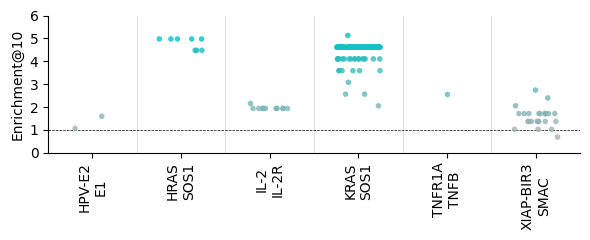

In [126]:
plt.figure(figsize=(6, 2.5))

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "gray_to_aqua",
    ["#B0B0B0", "#00C4C7"]  # gray → your color
)
family_order = sorted(inhibitor_embeddings_df['family'].unique())

ax = sns.stripplot(x='family', y='enrichment_at_k', data=inhibitor_embeddings_df,
              size=4, alpha=0.8, jitter=0.25, palette=cmap, hue='enrichment_at_k', order=family_order)
ax.get_legend().remove()
new_labels = [label.get_text().replace('/', '\n') for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.xticks(rotation=90)
plt.axhline(1.0, linestyle='--', color='black', linewidth=0.5)

plt.ylabel(f"Enrichment@{KAAAY}")
ax.set_yticks(range(7))
plt.xlabel("")

n_families = inhibitor_embeddings_df['family'].nunique()

for i in range(n_families - 1):
    plt.axvline(i + 0.5, color='lightgray', linewidth=0.5, zorder=0)

sns.despine()
plt.tight_layout()
plt.savefig(f"figures/plots/large_proteins_enrichment_at_k_{KAAAY}.svg")
plt.show()

/tmp/ipykernel_1341519/1201145628.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


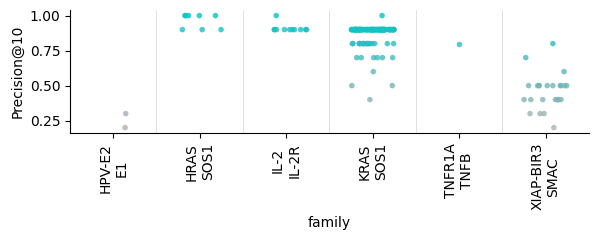

In [123]:
plt.figure(figsize=(6, 2.5))

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "gray_to_aqua",
    ["#B0B0B0", "#00C4C7"]  # gray → your color
)

family_order = sorted(inhibitor_embeddings_df['family'].unique())
ax = sns.stripplot(x='family', y='precision_at_k', data=inhibitor_embeddings_df,
              size=4, alpha=0.8, jitter=0.25, palette=cmap, hue='precision_at_k', order=family_order)
ax.get_legend().remove()
new_labels = [label.get_text().replace('/', '\n') for label in ax.get_xticklabels()]
ax.set_xticklabels(new_labels)
plt.xticks(rotation=90)

plt.ylabel(f"Precision@{KAAAY}")

n_families = inhibitor_embeddings_df['family'].nunique()

for i in range(n_families - 1):
    plt.axvline(i + 0.5, color='lightgray', linewidth=0.5, zorder=0)

plt.tight_layout()
sns.despine()
plt.savefig(f"figures/plots/large_proteins_precision_at_k_{KAAAY}.svg")
plt.show()

In [185]:
# Swarm plot, x = dist inhibitor-ppi, y = dist patch to target chain
k = 10

entry = inhibitor_embeddings_df.sort_values(by='precision_at_k', ascending=False).iloc[1]
print("Family: ", entry['family'])
closest_ppi_idx = np.argsort(entry['emb_dist'])[:k]
furthest_ppi_idx = np.argsort(entry['emb_dist'])[-k:]
random_ppi_idx = np.random.randint(0, len(entry['emb_dist']), size=(1, 100)).flatten()
ppi_idx = np.concatenate([closest_ppi_idx, furthest_ppi_idx, random_ppi_idx])
swarm_plot_data = {
    'Distance to Target Interface': entry['dist_to_target'][ppi_idx],
    'type': np.array([f'Top {k}'] * len(closest_ppi_idx) + [f'Bottom {k}'] * len(furthest_ppi_idx) + [f'Reference'] * len(random_ppi_idx))
}
swarm_plot_data = pd.DataFrame(swarm_plot_data)

topk_patch_ids = [entry['ppi_patch_ids'][i] for i in closest_ppi_idx]
bottomk_patch_ids = [entry['ppi_patch_ids'][i] for i in furthest_ppi_idx]
print(f"Top {k} patch IDs: {topk_patch_ids}")
print("Top center coordinates:", ppi_data.set_index('id').loc[topk_patch_ids[:3], 'center'].values)
print(f"Bottom {k} patch IDs: {bottomk_patch_ids}")
print("Bottom center coordinates:", ppi_data.set_index('id').loc[bottomk_patch_ids[:3], 'center'].values)

Family:  HRAS/SOS1
Top 10 patch IDs: ['1BKD_S_937', '1BKD_S_836', '1BKD_S_953', '1BKD_S_242', '1BKD_S_245', '1BKD_S_744', '1BKD_S_236', '1BKD_S_762', '1BKD_S_484', '1BKD_S_323']
Top center coordinates: [array([62.7813173 , 45.2888553 , 77.61843449])
 array([62.98307013, 45.16119757, 78.39051603])
 array([63.423216  , 46.06261606, 80.15693616])]
Bottom 10 patch IDs: ['1BKD_S_511', '1BKD_S_741', '1BKD_S_200', '1BKD_S_798', '1BKD_S_214', '1BKD_S_991', '1BKD_S_780', '1BKD_S_445', '1BKD_S_789', '1BKD_S_410']
Bottom center coordinates: [array([51.84727885, 48.30686841, 33.91000402])
 array([51.02457371, 27.23716619, 85.04025099])
 array([47.89779924, 27.48741451, 83.99666247])]


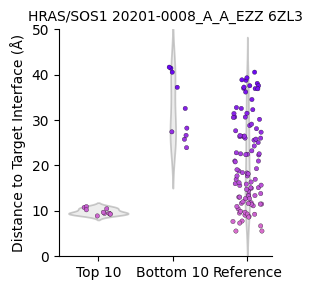

In [186]:
plt.figure(figsize=(3, 3))

# Draw violin first
ax = sns.violinplot(
    x='type',
    y='Distance to Target Interface',
    data=swarm_plot_data,
    color='lightgray',
    alpha=0.4,
    inner=None,
)

# Create colormap
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "gray_to_purple",
    ["#D86ECC", "#6805F2"]
)

# Get exact x positions used by seaborn
xticks = ax.get_xticks()
categories = [t.get_text() for t in ax.get_xticklabels()]
pos_dict = dict(zip(categories, xticks))

# Map each row to correct x position
x_vals = swarm_plot_data['type'].map(pos_dict).values

# Add jitter
jitter = np.random.uniform(-0.2, 0.2, size=len(x_vals))

sc = ax.scatter(
    x_vals + jitter,
    swarm_plot_data['Distance to Target Interface'],
    c=swarm_plot_data['Distance to Target Interface'],
    cmap=cmap,
    s=10,
    edgecolor='black',
    linewidth=0.2
)

sns.despine()

plt.ylabel('Distance to Target Interface (Å)')
plt.ylim(0, 50)
plt.xlabel('')
plt.title(f"{entry['family']} {entry['id']} {entry['pdb_code']}", fontsize=10)
plt.tight_layout()

plt.savefig(f"figures/plots/{entry['family'].replace('/','.')}_block_dist_vs_emb_dist_swarm.svg")
plt.show()

In [169]:
import numpy as np

def cumulative_hit_curve(E: np.ndarray,
                         G: np.ndarray,
                         geom_thresh: float = 8.0,
                         normalize_x: bool = True):
    """
    Compute cumulative hit curve for embedding vs geometric proximity.
    
    Parameters
    ----------
    E : np.ndarray
        Embedding distances (smaller = more similar)
    G : np.ndarray
        Geometric distances (smaller = closer in 3D)
    geom_thresh : float
        Threshold defining geometric "positive"
    normalize_x : bool
        If True, x-axis returned as percentile (0-1),
        otherwise as rank index (1..N)
    
    Returns
    -------
    x : np.ndarray
        Rank positions (percentile or absolute rank)
    cumulative_precision : np.ndarray
        Cumulative fraction of geometric positives up to each rank
    baseline : float
        Expected precision under random selection
    """
    E = np.asarray(E).reshape(-1)
    G = np.asarray(G).reshape(-1)
    assert E.shape == G.shape

    N = len(E)

    # Define geometric positives
    positives = (G <= geom_thresh).astype(int)

    # Sort by embedding distance (ascending)
    order = np.argsort(E)
    sorted_pos = positives[order]

    # Cumulative hits
    cumulative_hits = np.cumsum(sorted_pos)

    # Precision up to each rank
    ranks = np.arange(1, N + 1)
    cumulative_precision = cumulative_hits / ranks

    # X-axis scaling
    if normalize_x:
        x = ranks / N
    else:
        x = ranks

    # Random baseline (flat line)
    baseline = positives.mean()

    return x, cumulative_precision, baseline


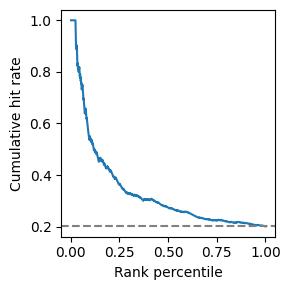

In [ ]:
x, cum_prec, baseline = cumulative_hit_curve(entry['emb_dist'], entry['dist_to_target'], geom_thresh=GEOM_THRESH)

plt.figure(figsize=(3,3))
plt.plot(x, cum_prec, label="Embedding ranking")
plt.axhline(baseline, linestyle="--", color="gray", label="Random baseline")
plt.xlabel("Rank percentile")
plt.ylabel("Cumulative hit rate")
plt.tight_layout()
plt.show()

In [161]:
import numpy as np

def precision_at_k_curve(E: np.ndarray,
                         G: np.ndarray,
                         geom_thresh: float = 8.0,
                         k_values=None):
    """
    Compute Precision@k curve for embedding vs geometric proximity.
    
    Parameters
    ----------
    E : np.ndarray
        Embedding distances (smaller = more similar)
    G : np.ndarray
        Geometric distances (smaller = closer)
    geom_thresh : float
        Threshold defining geometric positive
    k_values : list or array
        Values of k to evaluate (default: 1..N)
    
    Returns
    -------
    k_values : np.ndarray
        k values used
    precision : np.ndarray
        Precision@k for each k
    baseline : float
        Expected precision under random
    """
    E = np.asarray(E).reshape(-1)
    G = np.asarray(G).reshape(-1)
    assert E.shape == G.shape

    N = len(E)

    positives = (G <= geom_thresh).astype(int)

    # Sort by embedding similarity
    order = np.argsort(E)
    sorted_pos = positives[order]

    if k_values is None:
        k_values = np.arange(1, N + 1)

    precision = []
    for k in k_values:
        precision.append(sorted_pos[:k].mean())

    precision = np.array(precision)

    baseline = positives.mean()

    return np.array(k_values), precision, baseline

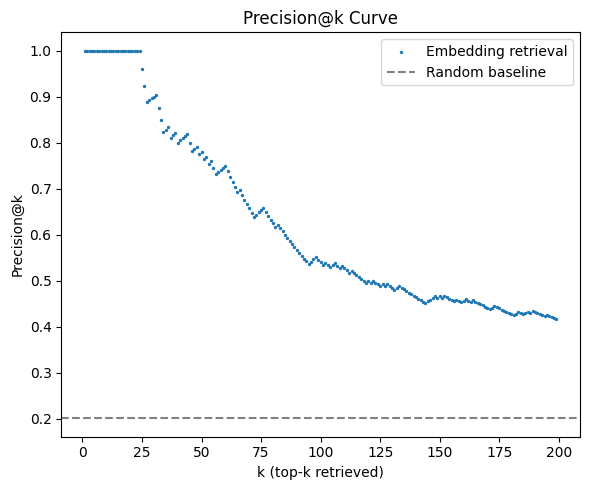

In [164]:
import matplotlib.pyplot as plt

k_vals = np.arange(1, 200)  # limit for readability
k, prec, baseline = precision_at_k_curve(entry['emb_dist'], entry['dist_to_target'], geom_thresh=GEOM_THRESH, k_values=k_vals)

plt.figure(figsize=(6,5))
plt.scatter(k, prec, label="Embedding retrieval", s=2)
plt.axhline(baseline, linestyle="--", color="gray", label="Random baseline")
plt.xlabel("k (top-k retrieved)")
plt.ylabel("Precision@k")
plt.legend()
plt.title("Precision@k Curve")
plt.tight_layout()
plt.show()

### Run retrieval for a specific family

In [15]:
ppi_embeddings_df = pd.read_parquet("PPI_Partner_interface_points_embeddings.parquet")
ppi_embeddings_df['family'] = ppi_embeddings_df['id'].str.split('_').str[0].map(ppis_to_family)
ppi_embeddings_families = set(ppi_embeddings_df['family'].unique())
families = list(set(inhibitor_embeddings_df['family'].unique()).intersection(ppi_embeddings_families))
print("Number of families: ", len(families))
print(families)

Number of families:  8
['IL-2/IL-2R', 'TNFR1A/TNFB', 'HRAS/SOS1', 'XIAP-BIR3/SMAC', 'KRAS/SOS1', 'TNFA/TNFA', 'INTEGRASE/LEDGF', 'HPV-E2/E1']


In [44]:
chosen_family = families[7]

In [45]:
df_ppi = ppi_embeddings_df[ppi_embeddings_df['family'] == chosen_family].copy()
df_inhibitor = inhibitor_embeddings_df[inhibitor_embeddings_df['family'] == chosen_family].copy()
if len(df_inhibitor) > 10:
    df_inhibitor = df_inhibitor[:10]
    print(f"Truncated inhibitor embeddings from {len(inhibitor_embeddings_df)} to 10")
df_dist = dist_df[dist_df['family'] == chosen_family].copy()

assert (df_dist['id'] == df_ppi['id']).all(), "Distances and PPI embeddings have different IDs"

print("Number of PPI embeddings: ", len(df_ppi))
print("Number of inhibitor embeddings: ", len(df_inhibitor))

ppi_embeddings = np.stack(df_ppi['graph_embedding'])
inhibitor_embeddings = np.stack(df_inhibitor['inhibitor_embedding'])
dist_to_target = np.array(df_dist['distance'].values)

metric = 'cosine'
dist = scipy.spatial.distance.cdist(inhibitor_embeddings, ppi_embeddings, metric=metric)

Number of PPI embeddings:  1000
Number of inhibitor embeddings:  2


In [46]:
df_inhibitor[['id', 'pdb_code']]

,id,pdb_code
445,20101-0001_A_A_434,1R6N
446,20101-0001_A_A_434,1R6N


In [47]:
(df_ppi['id'].str.split('_').str[0] + "_" + df_ppi['id'].str.split('_').str[1]).unique()

array(['1TUE_A'], dtype=object)

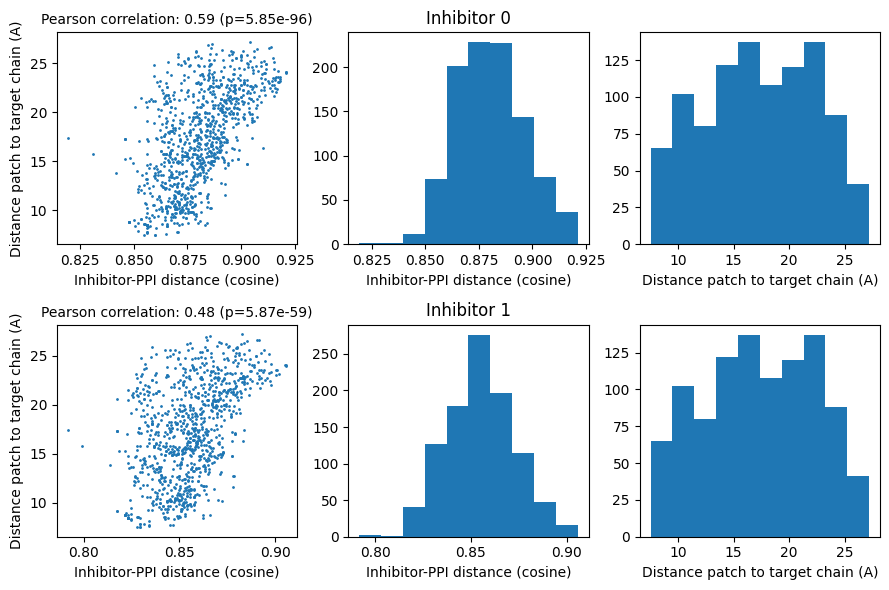

In [48]:
fig, ax = plt.subplots(len(df_inhibitor), 3, figsize=(9, 3 * len(df_inhibitor)))

for inhibitor_idx in range(len(df_inhibitor)):
    if len(df_inhibitor) == 1:
        ax0 = ax[0]
        ax1 = ax[1]
        ax2 = ax[2]
    else:
        ax0 = ax[inhibitor_idx, 0]
        ax1 = ax[inhibitor_idx, 1]
        ax2 = ax[inhibitor_idx, 2]

    pearson_corr, pval = scipy.stats.pearsonr(dist[inhibitor_idx], dist_to_target)
    ax0.scatter(dist[inhibitor_idx], dist_to_target, s=1)
    ax0.set_xlabel(f"Inhibitor-PPI distance ({metric})")
    ax0.set_ylabel("Distance patch to target chain (A)")
    ax0.set_title(f"Pearson correlation: {pearson_corr:.2f} (p={pval:.2e})", fontsize=10)

    ax1.hist(dist[inhibitor_idx])
    ax1.set_title(f"Inhibitor {inhibitor_idx}")
    ax1.set_xlabel(f"Inhibitor-PPI distance ({metric})")
    
    ax2.hist(dist_to_target)
    ax2.set_xlabel("Distance patch to target chain (A)")

plt.tight_layout()
plt.savefig(f"figures/large_protein_patches/{chosen_family.replace('/','.')}_correlation.png", dpi=300)
plt.show()

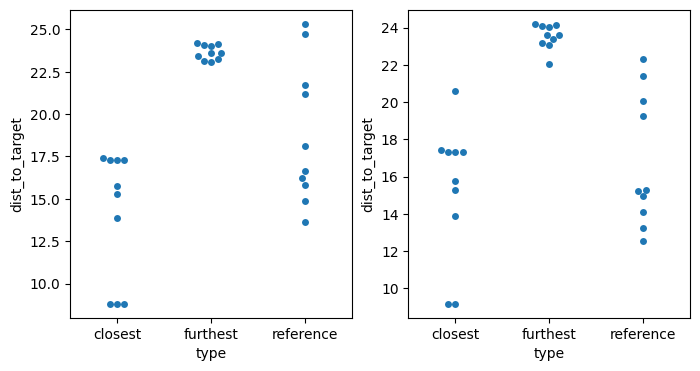

In [49]:
# Swarm plot, x = dist inhibitor-ppi, y = dist patch to target chain
k = 10

fig, ax = plt.subplots(1, len(df_inhibitor), figsize=(4 * len(df_inhibitor), 4))
for inhibitor_idx in range(len(df_inhibitor)):
    closest_ppi_idx = np.argsort(dist, axis=1)[inhibitor_idx, :k].flatten()
    furthest_ppi_idx = np.argsort(dist, axis=1)[inhibitor_idx, -k:].flatten()
    random_ppi_idx = np.random.randint(0, len(ppi_embeddings), size=(1, k)).flatten()
    ppi_idx = np.concatenate([closest_ppi_idx, furthest_ppi_idx, random_ppi_idx])

    swarm_plot_data = {
        'dist_to_target': dist_to_target[ppi_idx],
        'type': np.array(['closest'] * len(closest_ppi_idx) + ['furthest'] * len(furthest_ppi_idx) + ['reference'] * len(random_ppi_idx))
    }
    swarm_plot_data = pd.DataFrame(swarm_plot_data)

    if len(df_inhibitor) == 1:
        ax_ = ax
    else:
        ax_ = ax[inhibitor_idx]
    sns.swarmplot(x='type', y='dist_to_target', data=swarm_plot_data, ax=ax_)

plt.savefig(f"figures/large_protein_patches/{chosen_family.replace('/','.')}_dist_to_target.png", dpi=300)
plt.show()

/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 6.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


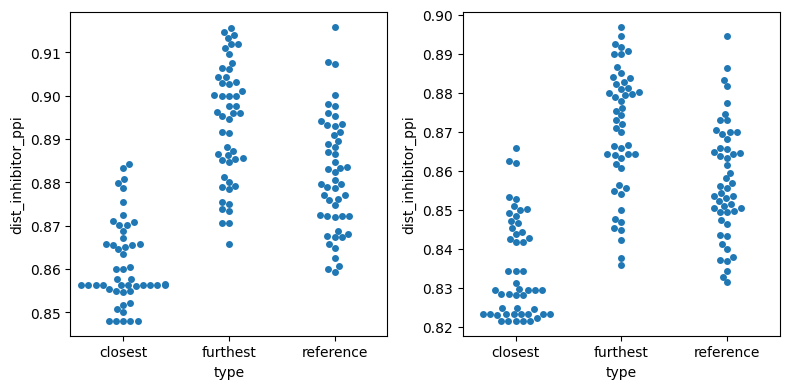

In [50]:
# Swarm plot, x = dist patch to target chain, y = dist inhibitor-ppi
k = 50

closest_dist_to_target = np.argsort(dist_to_target)[:k]
furthest_dist_to_target = np.argsort(dist_to_target)[-k:]
random_dist_to_target = np.random.randint(0, len(dist_to_target), size=(k))

fig, ax = plt.subplots(1, len(df_inhibitor), figsize=(4 * len(df_inhibitor), 4))
for inhibitor_idx in range(len(df_inhibitor)):
    ppi_inhibitor_dist1 = dist[inhibitor_idx, closest_dist_to_target].flatten()
    ppi_inhibitor_dist2 = dist[inhibitor_idx, furthest_dist_to_target].flatten()
    ppi_inhibitor_dist3 = dist[inhibitor_idx, random_dist_to_target].flatten()

    swarm_plot_data = {
        'dist_inhibitor_ppi': np.concatenate([ppi_inhibitor_dist1, ppi_inhibitor_dist2, ppi_inhibitor_dist3]),
        'type': np.array(['closest'] * len(ppi_inhibitor_dist1) + ['furthest'] * len(ppi_inhibitor_dist2) + ['reference'] * len(ppi_inhibitor_dist3))
    }
    swarm_plot_data = pd.DataFrame(swarm_plot_data)

    if len(df_inhibitor) == 1:
        ax_ = ax
    else:
        ax_ = ax[inhibitor_idx]

    sns.swarmplot(x='type', y='dist_inhibitor_ppi', data=swarm_plot_data, ax=ax_)
plt.tight_layout()
plt.savefig(f"figures/large_protein_patches/{chosen_family.replace('/','.')}_emb_dist_to_inhibitor.png", dpi=300)
plt.show()

## Retrieval with block embeddings

In [42]:
ppi_embeddings_df2 = pd.read_parquet('PPI_Partner_small_proteins_embeddings.parquet')
ppi_embeddings_df2['family'] = ppi_embeddings_df2['id'].str.split('_').str[0].map(ppis_to_family)
ppi_data2 = pd.read_parquet('PPI_Partner_small_proteins.parquet')

ppi_embeddings_df2 = pd.merge(ppi_embeddings_df2, ppi_data2, on='id', how='left')

In [64]:
block = []
for _, row in ppi_embeddings_df2.iterrows():
    assert len(row['B']) == len(row['block_embedding']), "Number of blocks and block embeddings do not match"
    curr_atom_idx = 0
    for idx, (block_id, block_length, block_embedding) in enumerate(zip(row['B'], row['block_lengths'], row['block_embedding'])):
        block_center = np.mean(np.stack(row['X'][curr_atom_idx:curr_atom_idx + block_length]), axis=0)
        curr_atom_idx += block_length
        block.append({
            "id": row['id'],
            "pdb_code": row['id'].split('_')[0],
            "chain": row['id'].split('_')[1],
            "block_idx": idx,
            "B": block_id,
            "block_embedding": block_embedding,
            "center": block_center,
            "family": row['family'],
        })
block_df = pd.DataFrame(block)
block_df['target_chain'] = block_df['pdb_code'].map(ppis_to_target_chain)
block_df['pdb_path'] = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datasets/2p2idb/2p2idb_2024-04-08_cifs/" + block_df['pdb_code'] + ".cif"
block_df = block_df[block_df['B'] != 3] # remove global block

In [65]:
dist_to_partner_chain = block_df.apply(
    lambda x: pd.Series(
        closest_residue_on_chain(
            x['pdb_path'],
            x['center'],
            x['target_chain'],
            atom_filter='ca'
        ),
        index=['resi', 'resn', 'distance']
    ),
    axis=1
)
block_df[['closest_resi', 'closest_resn', 'closest_dist']] = dist_to_partner_chain

In [180]:
families = list(set(ppi_embeddings_df2['family'].unique()).intersection(set(inhibitor_embeddings_df['family'].unique())))
print("Number of families: ", len(families))
families

Number of families:  13


['HDM2/P53',
 'MENIN/MLL',
 'BCL2/BAX',
 'BCLXL/BAK',
 'MKEAP1/MNRF2',
 'KEAP1/NRF2',
 'XDM2/P53',
 'DCN1/UBC12',
 'WDR5/MLL1',
 'BRD9/H4',
 'ZIPA/FTSZ',
 'MDM4/P53',
 'BRD4-1/H4']

In [181]:
chosen_family = families[5]
print(chosen_family)

KEAP1/NRF2


In [182]:
df_ppi = block_df[block_df['family'] == chosen_family].copy()
df_inhibitor = inhibitor_embeddings_df[inhibitor_embeddings_df['family'] == chosen_family].copy()

print("Number of PPI embeddings: ", len(df_ppi))
print("Number of inhibitor embeddings: ", len(df_inhibitor))

ppi_embeddings = np.stack(df_ppi['block_embedding'])
inhibitor_embeddings = np.stack(df_inhibitor['inhibitor_embedding'])
dist_to_target = np.array(df_ppi['closest_dist'].values)

metric = 'cosine'
dist = scipy.spatial.distance.cdist(inhibitor_embeddings, ppi_embeddings, metric=metric)

Number of PPI embeddings:  16
Number of inhibitor embeddings:  3


In [195]:
df_inhibitor

,X,B,A,atom_positions,block_lengths,segment_ids,block_to_pdb_indexes,id,graph_embedding,block_embedding,atom_embedding,block_id,atom_id,pdb_code,inhibitor_embedding,family
169,"[[44.15800341663745, 6.588463093535412, 14.217...","[3, 4, 11, 9, 19, 17, 20, 20, 4, 7, 19, 14, 14...","[2, 9, 8, 8, 10, 9, 8, 8, 10, 8, 8, 8, 8, 8, 8...","[2, 3, 4, 3, 3, 3, 4, 3, 3, 5, 6, 7, 7, 8, 8, ...","[1, 4, 12, 11, 11, 9, 6, 6, 4, 8, 11, 8, 8, 8,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{""1"": ""X_333"", ""2"": ""X_334"", ""3"": ""X_335"", ""4""...",10201-0003_X_X_12O,"[2.695773446248495e-06, -5.720377521356568e-05...","[[0.17674006521701813, 0.1966487318277359, 0.0...","[[0.09654022008180618, -0.07560421526432037, -...","[3, 4, 11, 9, 19, 17, 20, 20, 4, 7, 19, 14, 14...","[2, 9, 8, 8, 10, 9, 8, 8, 10, 8, 8, 8, 8, 8, 8...",4IFN,"[0.028167420532554388, 0.11764673419072226, -0...",KEAP1/NRF2
170,"[[44.87388620400488, -5.775632876711419, 13.16...","[3, 4, 11, 9, 19, 17, 20, 19, 20, 4, 7, 4, 19,...","[2, 9, 8, 8, 10, 9, 8, 8, 10, 8, 8, 8, 8, 8, 8...","[2, 3, 4, 3, 3, 3, 4, 3, 3, 5, 6, 7, 7, 8, 8, ...","[1, 4, 12, 11, 11, 9, 6, 11, 6, 4, 8, 4, 11, 8...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{""1"": ""X_333"", ""2"": ""X_334"", ""3"": ""X_335"", ""4""...",10201-0028_X_X_GFD,"[2.4734838007134385e-05, -2.5982877559727058e-...","[[0.19684363901615143, 0.20644031465053558, 0....","[[0.09654022008180618, -0.07560421526432037, -...","[3, 4, 11, 9, 19, 17, 20, 19, 20, 4, 7, 4, 19,...","[2, 9, 8, 8, 10, 9, 8, 8, 10, 8, 8, 8, 8, 8, 8...",7XM2,"[0.0626337910653092, 0.10120689100585878, -0.1...",KEAP1/NRF2
171,"[[44.872375859440986, -6.622904019002375, 13.1...","[3, 4, 11, 9, 19, 20, 19, 20, 4, 7, 4, 19, 14,...","[2, 9, 8, 8, 10, 9, 8, 8, 10, 8, 8, 8, 8, 8, 8...","[2, 3, 4, 3, 3, 3, 4, 3, 3, 5, 6, 7, 7, 8, 8, ...","[1, 4, 12, 11, 11, 6, 11, 6, 4, 8, 4, 11, 8, 8...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{""1"": ""X_333"", ""2"": ""X_334"", ""3"": ""X_335"", ""4""...",10201-0028_X_X_GFD,"[1.682948277448304e-05, -3.6065368476556614e-0...","[[0.18993230164051056, 0.20398736000061035, 0....","[[0.09654022008180618, -0.07560421526432037, -...","[3, 4, 11, 9, 19, 20, 19, 20, 4, 7, 4, 19, 14,...","[2, 9, 8, 8, 10, 9, 8, 8, 10, 8, 8, 8, 8, 8, 8...",7XM2,"[0.05850404384545982, 0.11079731257632375, -0....",KEAP1/NRF2


In [199]:
df_ppi

,id,pdb_code,chain,block_idx,B,block_embedding,center,family,target_chain,pdb_path,closest_resi,closest_resn,closest_dist
81,2FLU_P,2FLU,P,1,5,"[0.33242809772491455, 0.006991393398493528, 0....","[-16.037199783325196, 9.216800022125245, 4.875...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,386,GLY,14.129841
82,2FLU_P,2FLU,P,2,9,"[0.25625813007354736, 0.04911116510629654, 0.0...","[-16.640363693237305, 7.356090892444957, 1.543...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,386,GLY,16.547566
83,2FLU_P,2FLU,P,3,9,"[0.2948899269104004, 0.03775283694267273, 0.01...","[-14.05654543096369, 4.200909072702581, 6.2412...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,386,GLY,12.144957
84,2FLU_P,2FLU,P,4,5,"[0.26205888390541077, 0.012804732657968998, 0....","[-10.187800025939941, 4.721199941635132, 2.102...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,386,GLY,12.331775
85,2FLU_P,2FLU,P,5,17,"[0.24920853972434998, -0.005806951317936182, 0...","[-6.8507777320014105, 1.6039999624093373, 0.87...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,384,PRO,12.175632
86,2FLU_P,2FLU,P,6,7,"[0.23221038281917572, 0.055935949087142944, 0....","[-3.933500051498413, 3.330000028014183, 2.9026...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,384,PRO,9.468366
87,2FLU_P,2FLU,P,7,17,"[0.19172851741313934, 0.010623213835060596, 0....","[-2.596555554204517, 5.926333374447292, -1.450...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,382,ASN,13.671773
88,2FLU_P,2FLU,P,8,7,"[0.23278452455997467, 0.038131482899188995, 0....","[2.615124948322773, 4.91700005531311, -1.68662...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,574,GLY,8.686857
89,2FLU_P,2FLU,P,9,12,"[0.20509669184684753, -0.007565285544842482, 0...","[4.806250035762787, 8.632749915122986, -0.2026...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,574,GLY,9.309226
90,2FLU_P,2FLU,P,10,15,"[0.13709495961666107, 0.05359482765197754, 0.0...","[6.905400085449219, 7.746399879455566, -3.5263...",KEAP1/NRF2,X,/n/holylfs06/LABS/mzitnik_lab/Lab/afang/datase...,574,GLY,6.437818


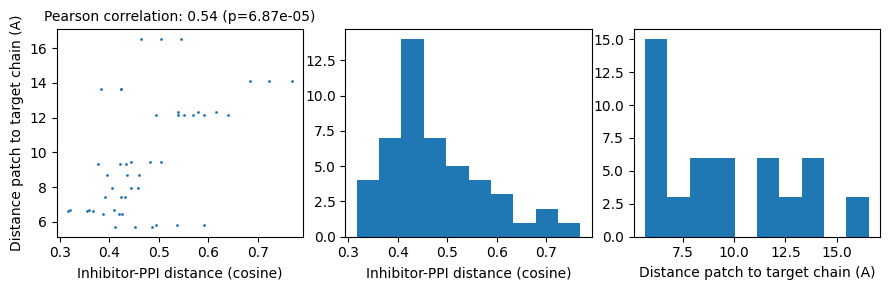

In [183]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

dist_to_target_ = np.stack([dist_to_target] * len(inhibitor_embeddings)).flatten()

pearson_corr, pval = scipy.stats.pearsonr(dist.flatten(), dist_to_target_)
ax0.scatter(dist.flatten(), dist_to_target_, s=1)
ax0.set_xlabel(f"Inhibitor-PPI distance ({metric})")
ax0.set_ylabel("Distance patch to target chain (A)")
ax0.set_title(f"Pearson correlation: {pearson_corr:.2f} (p={pval:.2e})", fontsize=10)

ax1.hist(dist.flatten())
ax1.set_xlabel(f"Inhibitor-PPI distance ({metric})")

ax2.hist(dist_to_target_)
ax2.set_xlabel("Distance patch to target chain (A)")

plt.tight_layout()
plt.savefig(f"figures/small_proteins/{chosen_family.replace('/','.')}_correlation.png", dpi=300)
plt.show()

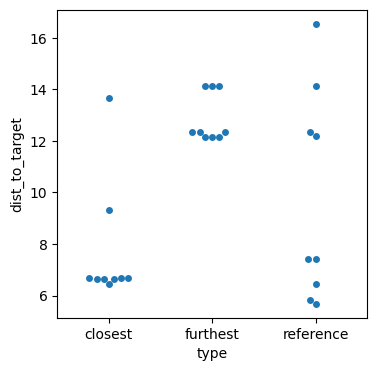

In [192]:
# Swarm plot, x = dist inhibitor-ppi, y = dist patch to target chain
k = 3

plt.figure(figsize=(4, 4))
closest_ppi_idx = np.argsort(dist, axis=1)[:, :k].flatten()
furthest_ppi_idx = np.argsort(dist, axis=1)[:, -k:].flatten()
random_ppi_idx = np.random.randint(0, len(ppi_embeddings), size=(len(inhibitor_embeddings), k)).flatten()
ppi_idx = np.concatenate([closest_ppi_idx, furthest_ppi_idx, random_ppi_idx])

swarm_plot_data = {
    'dist_to_target': dist_to_target[ppi_idx],
    'type': np.array(['closest'] * len(closest_ppi_idx) + ['furthest'] * len(furthest_ppi_idx) + ['reference'] * len(random_ppi_idx))
}
swarm_plot_data = pd.DataFrame(swarm_plot_data)

sns.swarmplot(x='type', y='dist_to_target', data=swarm_plot_data)

plt.savefig(f"figures/small_proteins/{chosen_family.replace('/','.')}_dist_to_target.png", dpi=300)
plt.show()

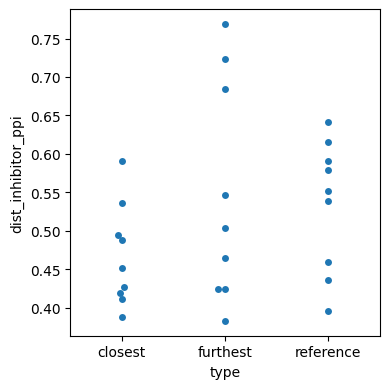

In [194]:
# Swarm plot, x = dist patch to target chain, y = dist inhibitor-ppi
k = 3

closest_dist_to_target = np.argsort(dist_to_target)[:k]
furthest_dist_to_target = np.argsort(dist_to_target)[-k:]
random_dist_to_target = np.random.randint(0, len(dist_to_target), size=(k))

plt.figure(figsize=(4, 4))
ppi_inhibitor_dist1 = dist[:, closest_dist_to_target].flatten()
ppi_inhibitor_dist2 = dist[:, furthest_dist_to_target].flatten()
ppi_inhibitor_dist3 = dist[:, random_dist_to_target].flatten()

swarm_plot_data = {
    'dist_inhibitor_ppi': np.concatenate([ppi_inhibitor_dist1, ppi_inhibitor_dist2, ppi_inhibitor_dist3]),
    'type': np.array(['closest'] * len(ppi_inhibitor_dist1) + ['furthest'] * len(ppi_inhibitor_dist2) + ['reference'] * len(ppi_inhibitor_dist3))
}
swarm_plot_data = pd.DataFrame(swarm_plot_data)

sns.swarmplot(x='type', y='dist_inhibitor_ppi', data=swarm_plot_data)
plt.tight_layout()
plt.savefig(f"figures/small_proteins/{chosen_family.replace('/','.')}_emb_dist_to_inhibitor.png", dpi=300)
plt.show()